# Anomaly Detection on UNSW NB-15 Dataset using iForest

In [1]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.2 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    f1_score, accuracy_score
)


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
train_df = pd.read_csv('/content/drive/MyDrive/UNSW Datasets/UNSW_NB15_training-set.csv')
test_df = pd.read_csv('/content/drive/MyDrive/UNSW Datasets/UNSW_NB15_testing-set.csv')

In [5]:
train_df.shape, test_df.shape

((175341, 45), (82332, 45))

## EDA & Preprocessing

In [6]:
from category_encoders import TargetEncoder

train_df.replace([np.inf, -np.inf], np.nan, inplace=True)
train_df.dropna(inplace=True)

In [7]:
train_df.columns

Index(['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes',
       'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss',
       'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin',
       'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth',
       'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm',
       'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm',
       'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm',
       'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label'],
      dtype='object')

In [8]:
train_df.label.value_counts()

,count
label,
1,119341
0,56000


In [9]:
test_df.label.value_counts()

,count
label,
1,45332
0,37000


In [10]:
for col in train_df.columns:
    if train_df[col].dtype == 'object':
        print(f"--- Column: {col} ---")
        print(train_df[col].value_counts())
        print("\n")

--- Column: proto ---
proto
tcp       79946
udp       63283
unas      12084
arp        2859
ospf       2595
          ...  
argus        98
netblt       98
igmp         18
icmp         15
rtp           1
Name: count, Length: 133, dtype: int64


--- Column: service ---
service
-           94168
dns         47294
http        18724
smtp         5058
ftp-data     3995
ftp          3428
ssh          1302
pop3         1105
dhcp           94
snmp           80
ssl            56
irc            25
radius         12
Name: count, dtype: int64


--- Column: state ---
state
INT    82275
FIN    77825
CON    13152
REQ     1991
RST       83
ECO       12
PAR        1
URN        1
no         1
Name: count, dtype: int64


--- Column: attack_cat ---
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: coun

Drop attack_cat col completely , Label encoding in state col and for service and protocol let's create one interaction term as they are likely dependent and do target encoding

In [11]:
train_df.drop(columns=['attack_cat'], inplace=True, errors='ignore');
test_df.drop(columns=['attack_cat'], inplace=True, errors='ignore');

le = LabelEncoder()

# Ensure 'state' columns are string type before encoding
train_df['state'] = train_df['state'].astype(str)
test_df['state'] = test_df['state'].astype(str)

# Combine unique states from both train and test for fitting
all_states = pd.concat([train_df['state'], test_df['state']], axis=0).unique()
le.fit(all_states)

train_df['state'] = le.transform(train_df['state'])
test_df['state'] = le.transform(test_df['state'])

In [12]:
print(train_df.groupby('proto')['service'].value_counts().head(30))
print(test_df.groupby('proto')['service'].value_counts().head(30))

proto        service
3pc          -           100
a/n          -           100
aes-sp3-d    -           100
any          -           300
argus        -            98
aris         -           100
arp          -          2859
ax.25        -           100
bbn-rcc      -            98
bna          -           100
br-sat-mon   -           100
cbt          -            99
cftp         -           100
chaos        -            99
compaq-peer  -           100
cphb         -           100
cpnx         -           100
crtp         -            99
crudp        -           100
dcn          -            99
ddp          -           100
ddx          -           100
dgp          -           100
egp          -            98
eigrp        -           100
emcon        -            99
encap        -           100
etherip      -           100
fc           -           100
fire         -           100
Name: count, dtype: int64
proto        service
3pc          -           32
a/n          -           32
aes-sp

In [13]:
proto_service_counts = train_df.groupby('proto')['service'].nunique()
meaningful_protos = proto_service_counts[proto_service_counts > 1]
print("Protocols with actual service variety:")
print(meaningful_protos)

print(train_df[train_df['proto'].isin(meaningful_protos.index)]
      .groupby('proto')['service'].value_counts())

Protocols with actual service variety:
proto
tcp    10
udp     5
Name: service, dtype: int64
proto  service 
tcp    -           46208
       http        18724
       smtp         5058
       ftp-data     3995
       ftp          3428
       ssh          1302
       pop3         1105
       ssl            56
       dns            45
       irc            25
udp    dns         47249
       -           15848
       dhcp           94
       snmp           80
       radius         12
Name: count, dtype: int64


So tcp and udp have multiple services whereas other protocols basically have '-' in service column so for all of the other protocols we can drop the services col and for tcp and udp create a proto+service term and do target encoding

In [14]:
def encode_proto_service(proto, service):
    if proto in ['tcp', 'udp']:
        return f"{proto}_{service}"
    else:
        return proto

train_df['proto_service'] = train_df.apply(
    lambda r: encode_proto_service(r['proto'], r['service']), axis=1
)
test_df['proto_service'] = test_df.apply(
    lambda r: encode_proto_service(r['proto'], r['service']), axis=1
)
print(f"Unique proto_service combos in train: {train_df['proto_service'].nunique()}")
print(train_df['proto_service'].value_counts().head(15))
train_df.drop(columns=['proto', 'service'], inplace=True)
test_df.drop(columns=['proto', 'service'], inplace=True)

te = TargetEncoder(cols=['proto_service'])
train_df['proto_service'] = te.fit_transform(train_df['proto_service'], train_df['label'])
test_df['proto_service']  = te.transform(test_df['proto_service'])

Unique proto_service combos in train: 146
proto_service
udp_dns         47249
tcp_-           46208
tcp_http        18724
udp_-           15848
unas            12084
tcp_smtp         5058
tcp_ftp-data     3995
tcp_ftp          3428
arp              2859
ospf             2595
tcp_ssh          1302
sctp             1150
tcp_pop3         1105
any               300
gre               225
Name: count, dtype: int64


In [15]:
X_train = train_df.drop(columns=['label'])
y_train = train_df['label']

X_test = test_df.drop(columns=['label'])
y_test = test_df['label']

In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [17]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X_test.columns)

print(f'Train: {X_train_scaled.shape} | Test: {X_test_scaled.shape}')

Train: (175341, 42) | Test: (82332, 42)


## Feature Selection from the feature imporatnces of Random Forest


Since there is a problem of dimensionality with isolation forest and model we will be reducing the feature set using the most important features identified by random forest model on this dataset

In [18]:
all_ranked_features = [
    'sttl',           # 0.1270
    'ct_state_ttl',   # 0.1231
    'dload',          # 0.0674
    'rate',           # 0.0629
    'sload',          # 0.0537
    'dttl',           # 0.0452
    'dmean',          # 0.0428
    'ackdat',         # 0.0420
    'smean',          # 0.0294
    'ct_srv_dst',     # 0.0282  ← Top 10
    'sbytes',         # 0.0280
    'synack',         # 0.0272
    'dinpkt',         # 0.0270
    'tcprtt',         # 0.0228
    'ct_srv_src',     # 0.0227  ← Top 15
    'proto_service',  # The column we just feature engineered
    'dbytes',         # 0.0224
    'dur',            # 0.0222
    'ct_dst_src_ltm', # 0.0221
    'sinpkt',         # 0.0201
    'sjit',           # 0.0198  ← Top 20
]

#### Adjust later
top_features = all_ranked_features[:16]
X_train_sel = X_train_scaled[top_features]
X_test_sel  = X_test_scaled[top_features]

print(f"Train shape: {X_train_sel.shape}")
print(f"Test shape:  {X_test_sel.shape}")

Train shape: (175341, 16)
Test shape:  (82332, 16)


✅ Natural threshold found: 0.0162


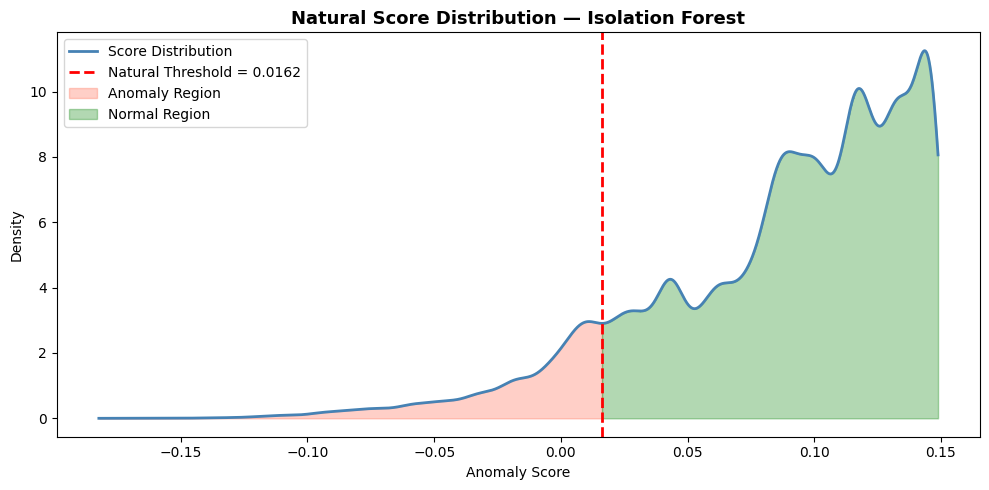

              precision    recall  f1-score   support

      Normal       0.42      0.82      0.56     37000
      Attack       0.39      0.09      0.15     45332

    accuracy                           0.42     82332
   macro avg       0.41      0.46      0.35     82332
weighted avg       0.40      0.42      0.33     82332



In [19]:
iso_forest = IsolationForest(
    n_estimators=200,
    contamination='auto',
    random_state=42,
    n_jobs=-1
)
iso_forest.fit(X_train_sel)

train_scores = iso_forest.decision_function(X_train_sel)

from scipy.stats import gaussian_kde

scores_sorted = np.sort(train_scores)
kde = gaussian_kde(train_scores)
kde_values = kde(scores_sorted)

from scipy.signal import argrelmin
valleys = argrelmin(kde_values, order=50)[0]

if len(valleys) > 0:
    natural_threshold = scores_sorted[valleys[0]]
    print(f"✅ Natural threshold found: {natural_threshold:.4f}")
else:
    natural_threshold = train_scores.mean()
    print(f"⚠️ No clear valley found, using mean: {natural_threshold:.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(scores_sorted, kde_values, color='steelblue', lw=2, label='Score Distribution')
ax.axvline(natural_threshold, color='red', linestyle='--', lw=2,
           label=f'Natural Threshold = {natural_threshold:.4f}')
ax.fill_between(scores_sorted, kde_values,
                where=(scores_sorted < natural_threshold),
                alpha=0.3, color='tomato', label='Anomaly Region')
ax.fill_between(scores_sorted, kde_values,
                where=(scores_sorted >= natural_threshold),
                alpha=0.3, color='green', label='Normal Region')
ax.set_xlabel('Anomaly Score')
ax.set_ylabel('Density')
ax.set_title('Natural Score Distribution — Isolation Forest', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

test_scores = iso_forest.decision_function(X_test_sel)
y_pred = np.where(test_scores < natural_threshold, 1, 0)

print(classification_report(y_test, y_pred, target_names=['Normal', 'Attack']))

Now, let's re-train the One-Class SVM with the scaled selected features.

In [20]:
X_train_normal = X_train_sel[y_train == 0]
print(f"Training on {len(X_train_normal)}")
print(f"Test set: {len(X_test_sel):,} samples")

Training on 56000
Test set: 82,332 samples



Training One-Class SVM...

Predicted → Normal: 51,107 | Anomaly: 31,225
Actual    → Normal: 37,000 | Anomaly: 45,332

       ONE-CLASS SVM — CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Normal       0.60      0.83      0.70     37000
      Attack       0.80      0.55      0.65     45332

    accuracy                           0.68     82332
   macro avg       0.70      0.69      0.68     82332
weighted avg       0.71      0.68      0.67     82332

ROC-AUC: 0.7585


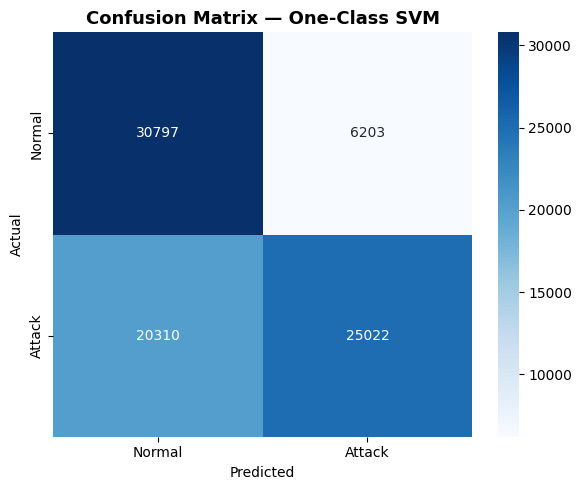

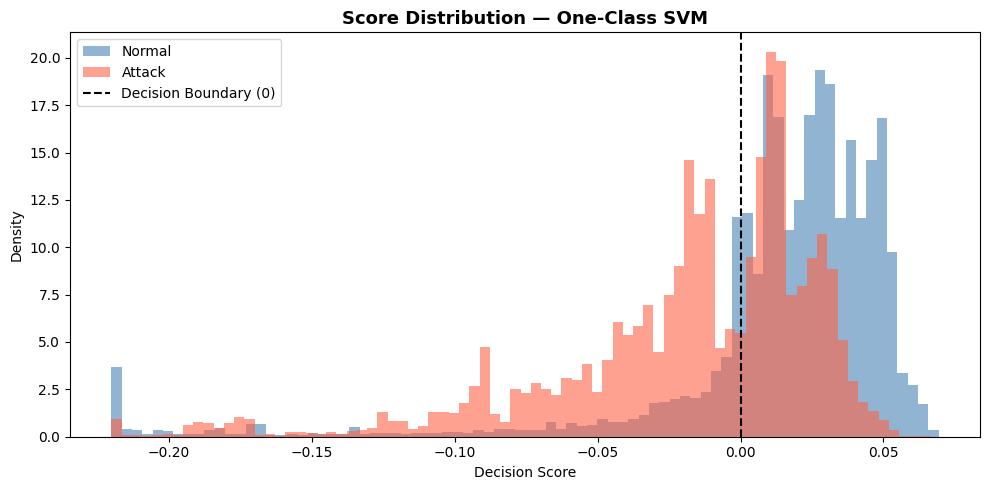

In [26]:
from sklearn.linear_model import SGDOneClassSVM
from sklearn.kernel_approximation import Nystroem
from sklearn.pipeline import make_pipeline



ocsvm = make_pipeline(
    Nystroem(
        kernel='rbf',
        gamma=None,
        n_components=300,
        random_state=42
    ),
    SGDOneClassSVM(
        nu=0.1,
        learning_rate='optimal',
        max_iter=1000,
        random_state=42,
        tol=1e-4
    )
)

# Fit ONLY on normal traffic
print("\nTraining One-Class SVM...")
ocsvm.fit(X_train_normal)

y_pred_raw    = ocsvm.predict(X_test_sel)
y_pred_scores = ocsvm.decision_function(X_test_sel)
y_pred = np.where(y_pred_raw == -1, 1, 0)
print(f"\nPredicted → Normal: {(y_pred==0).sum():,} | Anomaly: {(y_pred==1).sum():,}")
print(f"Actual    → Normal: {(y_test==0).sum():,} | Anomaly: {(y_test==1).sum():,}")

# Evaluation
print("\n" + "="*60)
print("       ONE-CLASS SVM — CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred, target_names=['Normal', 'Attack']))
print(f"ROC-AUC: {roc_auc_score(y_test, -y_pred_scores):.4f}")
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'], ax=ax)
ax.set_title('Confusion Matrix — One-Class SVM', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(y_pred_scores[y_test == 0], bins=80, alpha=0.6,
        color='steelblue', density=True, label='Normal')
ax.hist(y_pred_scores[y_test == 1], bins=80, alpha=0.6,
        color='tomato', density=True, label='Attack')
ax.axvline(0, color='black', linestyle='--', lw=1.5, label='Decision Boundary (0)')
ax.set_xlabel('Decision Score')
ax.set_ylabel('Density')
ax.set_title('Score Distribution — One-Class SVM', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

Computed gamma: 0.053230

Training One-Class SVM...

Predicted → Normal: 54,750 | Anomaly: 27,582
Actual    → Normal: 37,000 | Anomaly: 45,332

       ONE-CLASS SVM — CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Normal       0.56      0.84      0.67     37000
      Attack       0.78      0.47      0.59     45332

    accuracy                           0.64     82332
   macro avg       0.67      0.65      0.63     82332
weighted avg       0.68      0.64      0.63     82332

ROC-AUC: 0.7185


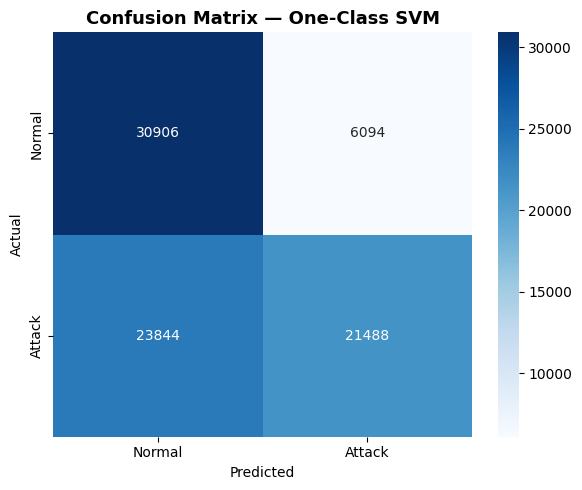

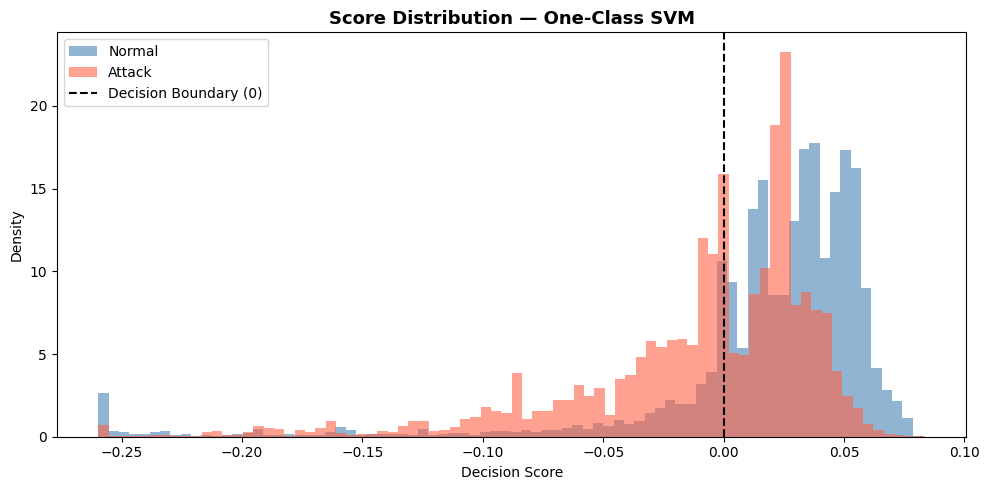

In [27]:
gamma = 1 / (X_train_normal.shape[1] * X_train_normal.values.var())
print(f"Computed gamma: {gamma:.6f}")

ocsvm = make_pipeline(
    Nystroem(
        kernel='rbf',
        gamma=gamma,
        n_components=500,
        random_state=42
    ),
    SGDOneClassSVM(
        nu=0.1,
        learning_rate='optimal',
        max_iter=1000,
        random_state=42,
        tol=1e-4
    )
)

# Fit ONLY on normal traffic
print("\nTraining One-Class SVM...")
ocsvm.fit(X_train_normal)

y_pred_raw    = ocsvm.predict(X_test_sel)
y_pred_scores = ocsvm.decision_function(X_test_sel)
y_pred = np.where(y_pred_raw == -1, 1, 0)
print(f"\nPredicted → Normal: {(y_pred==0).sum():,} | Anomaly: {(y_pred==1).sum():,}")
print(f"Actual    → Normal: {(y_test==0).sum():,} | Anomaly: {(y_test==1).sum():,}")

# Evaluation
print("\n" + "="*60)
print("       ONE-CLASS SVM — CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred, target_names=['Normal', 'Attack']))
print(f"ROC-AUC: {roc_auc_score(y_test, -y_pred_scores):.4f}")
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'], ax=ax)
ax.set_title('Confusion Matrix — One-Class SVM', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(y_pred_scores[y_test == 0], bins=80, alpha=0.6,
        color='steelblue', density=True, label='Normal')
ax.hist(y_pred_scores[y_test == 1], bins=80, alpha=0.6,
        color='tomato', density=True, label='Attack')
ax.axvline(0, color='black', linestyle='--', lw=1.5, label='Decision Boundary (0)')
ax.set_xlabel('Decision Score')
ax.set_ylabel('Density')
ax.set_title('Score Distribution — One-Class SVM', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [31]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.9, random_state=42)
pca.fit(X_train_normal)
print(f"Components to explain 90% normal variance: {pca.n_components_}")

X_train_pca = pca.transform(X_train_normal)
X_test_pca  = pca.transform(X_test_sel)

gamma_pca = 1 / (X_train_pca.shape[1] * X_train_pca.var())

ocsvm_pca = make_pipeline(
    Nystroem(kernel='rbf', gamma=gamma_pca,
             n_components=500, random_state=42),
    SGDOneClassSVM(nu=0.1, random_state=42, max_iter=1000)
)
ocsvm_pca.fit(X_train_pca)

scores_pca = ocsvm_pca.decision_function(X_test_pca)
preds_pca  = np.where(ocsvm_pca.predict(X_test_pca) == -1, 1, 0)

print(classification_report(y_test, preds_pca,
      target_names=['Normal', 'Attack']))
print(f"ROC-AUC: {roc_auc_score(y_test, -scores_pca):.4f}")

Components to explain 90% normal variance: 8
              precision    recall  f1-score   support

      Normal       0.71      0.83      0.76     37000
      Attack       0.84      0.72      0.77     45332

    accuracy                           0.77     82332
   macro avg       0.77      0.77      0.77     82332
weighted avg       0.78      0.77      0.77     82332

ROC-AUC: 0.7822


This is so far the highest we got using unsupervised learning